In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
pd.set_option('display.max_columns', 1000)
pd.set_option('display.float_format', lambda x : '%4f' %x )
pd.set_option('display.max_rows',1000)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/bike_sharing.csv')

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16
1,1/1/2011 1:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40
2,1/1/2011 2:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32
3,1/1/2011 3:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13
4,1/1/2011 4:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1


# 1]EDA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
# changing datetime  type to datetime from object

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [ ]:
df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.230860,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.791590,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


<function matplotlib.pyplot.show(close=None, block=None)>

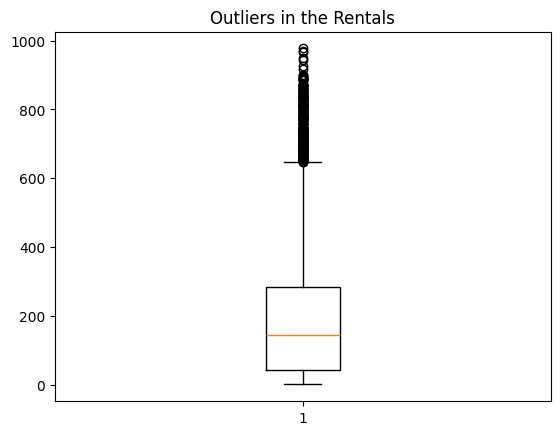

In [ ]:
plt.boxplot (df['count'])
plt.title('Outliers in the Rentals')
plt.show
#Here we cans ee there are outlers means there is very high demands in those periods , we wont remove outliers cause we need to make business decisions  and those outliers are business spikes.

# 2]DATA EXPLORATION

In [ ]:
# here we are gonna do feature enginering that gives insights

In [ ]:
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day_name()

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday


# There are few columns right now in numbers but they actually represnts category , so have to convert them in python/

In [ ]:
# renaming the categorical columns

season_map = {1:'Spring', 2: 'Summer', 3: 'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Cloudy', 3: 'Light rain/snow', 4:'Severe'}

df['season_label'] = df['season'].map(season_map)
df['weather_label'] = df['season'].map(weather_map)

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day,season_label,weather_label
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday,Spring,Clear
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday,Spring,Clear
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday,Spring,Clear
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday,Spring,Clear
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday,Spring,Clear


In [ ]:
df.isnull().sum() #  this makes sure there none null vlaeus in data

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


Validation check - means chekcing data is correct or not

In [ ]:
(df['casual']+df['registered'] == df['count']).all()

np.True_

# 3]Feature Engineering


In [ ]:
df['casual_ratio'] = df['casual'] / df['count']
df['registered_ratio'] = df['registered'] / df['count']

In [ ]:
df['temp_bucket'] = pd.cut(df['temp'], bins=5)
df['humidity_bucket'] = pd.cut(df['humidity'], bins=5)

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day,season_label,weather_label,casual_ratio,registered_ratio,temp_bucket,humidity_bucket
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday,Spring,Clear,0.187500,0.812500,"(8.856, 16.892]","(80.0, 100.0]"
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday,Spring,Clear,0.200000,0.800000,"(8.856, 16.892]","(60.0, 80.0]"
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday,Spring,Clear,0.156250,0.843750,"(8.856, 16.892]","(60.0, 80.0]"
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday,Spring,Clear,0.230769,0.769231,"(8.856, 16.892]","(60.0, 80.0]"
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday,Spring,Clear,0.000000,1.000000,"(8.856, 16.892]","(60.0, 80.0]"


# 4] Answering Business Questions and visulatzations

Q1] What factors affecting the Demands of Rentals?

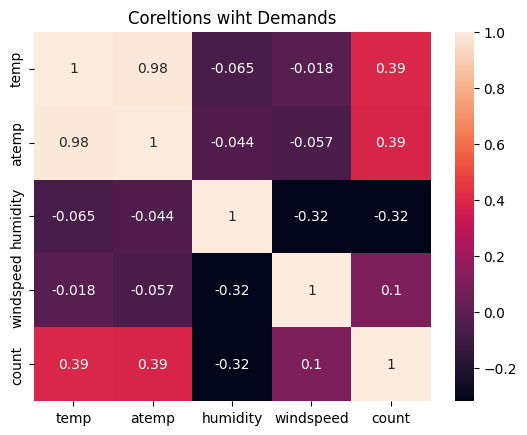

In [ ]:
corr = df[['temp','atemp','humidity','windspeed','count']].corr()

sns.heatmap(corr,annot = True)
plt.title('Coreltions wiht Demands')
plt.show()


  
The key points which we take away from the above graph :
/
- temp has correlation around +0.39 with count - Temperature is positively correlted with number of bikes being rented- the value is  +0.39 (which is a moderate positive correlation)
  As temperature increases → rentals increase
- We see similar correlation with atemp- which is the feel like temperature - this is because both temp and atemp are almost in similar range
- Humidity → -0.32 (moderately negative correlated with count) --> Meaning: As humidity increases → rentals decrease
- Windspeed → +0.10 (very weak)- Almost no relationship

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day,season_label,weather_label,casual_ratio,registered_ratio,temp_bucket,humidity_bucket
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday,Spring,Clear,0.187500,0.812500,"(8.856, 16.892]","(80.0, 100.0]"
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday,Spring,Clear,0.200000,0.800000,"(8.856, 16.892]","(60.0, 80.0]"
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday,Spring,Clear,0.156250,0.843750,"(8.856, 16.892]","(60.0, 80.0]"
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday,Spring,Clear,0.230769,0.769231,"(8.856, 16.892]","(60.0, 80.0]"
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday,Spring,Clear,0.000000,1.000000,"(8.856, 16.892]","(60.0, 80.0]"


Q2] How does demand changes across temperature Ranges?

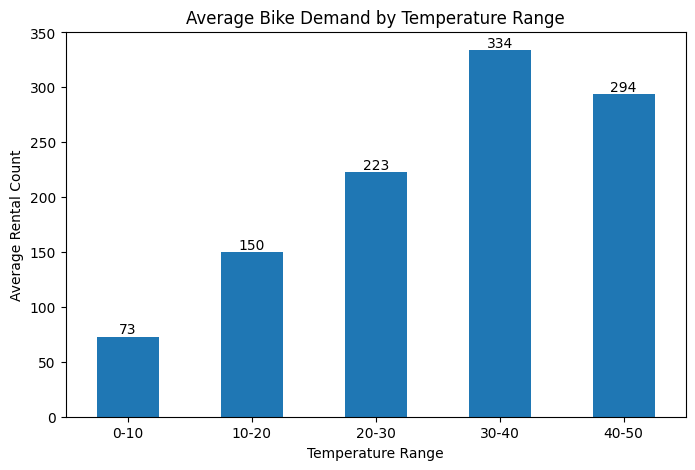

In [ ]:
# Create Temperature Buckets

bins = [0,10,20,30,40,50]

labels = ['0-10','10-20','20-30','30-40','40-50']

#This will put temperatues into ranges propely
df['temp_bucket']= pd.cut(df['temp'],
                          bins= bins,
                          labels = labels,
                          include_lowest = True)
# Here we need calculate averages od demands against temperatue
# why avg not sum cause sum will give count but that wont be helpfull but on other hand average will give clear idea of trend


# Here we used .roound(0) - it will round off figure, astype- strictly integer type
temp_analysis = (
    df.groupby('temp_bucket')
    ['count'].mean().round(0).astype(int).sort_index()
)


# now we are plotting chart using matplot and seborn

ax = temp_analysis.plot(kind='bar', figsize=(8, 5))

# This above will create oue chart but we need values on it so using inbuitl fucntion rather than doing loops
#  This bar_label funtions will automatically add vlaeus to top and contianers make sure it starst from group 1


ax.bar_label(ax.containers[0])

ax.set_title("Average Bike Demand by Temperature Range")
ax.set_xlabel("Temperature Range")
ax.set_ylabel("Average Rental Count")

ax.tick_params(axis='x', labelrotation=0)

plt.show()



In the above graph -- the x axis is the temp_bucket we just created, and in the y axis is the number of average rentals of bikes

Interpretation

This chart shows how bike rental demand changes across different temperature bins.

👉 We can see, Demand increases steadily from 73 to 150 to 223 as temperature rises

👉 We also see, temperature Peaks at 30–40°C, and Then slightly drops after that

Business interpretation
The first business interpretation is -  Demand is weather-driven.

“Bike usage increases significantly in warmer conditions, indicating that temperature plays a key role in user behavior.”

And the second business interpretation is —

“The highest demand occurs between 30–40°C, which can be considered as a peak operating window for maximizing rentals.”

Q3] Are casual user are more sensitive to the weather than the registers suers?

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day,season_label,weather_label,casual_ratio,registered_ratio,temp_bucket,humidity_bucket
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday,Spring,Clear,0.187500,0.812500,0-10,"(80.0, 100.0]"
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday,Spring,Clear,0.200000,0.800000,0-10,"(60.0, 80.0]"
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday,Spring,Clear,0.156250,0.843750,0-10,"(60.0, 80.0]"
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday,Spring,Clear,0.230769,0.769231,0-10,"(60.0, 80.0]"
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday,Spring,Clear,0.000000,1.000000,0-10,"(60.0, 80.0]"


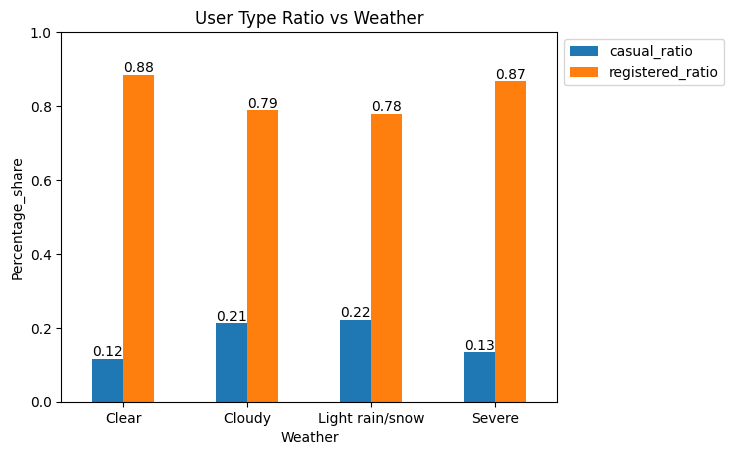

In [ ]:
weather_ratio = df.groupby('weather_label')[['casual_ratio', 'registered_ratio']].mean()

#  here we will segeate groups by the weather type
# the for each type , it calculates the avg

# After this we are plotting bar chart

ax= weather_ratio.plot(kind='bar')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim(0,1.0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.title("User Type Ratio vs Weather")
plt.xlabel("Weather")
plt.ylabel("Percentage_share")
plt.xticks(rotation=0)
plt.show()

In this graph, the x-axis represents weather conditions, while the y-axis represents the ratio of casual and registered users. The blue bars represent casual users, and the orange bars represent registered users.

Based on the above graph:

👉 Casual user share increases from clear weather (12%) to cloudy weather (21%) and reaches its highest level during light rain/snow (22%), before dropping to 13% during severe weather.

👉 Registered users show the opposite pattern, decreasing from 88% in clear weather to 78% during light rain/snow, before increasing again to 87% during severe weather.

5) Deep Insight — Business Interpretation

The data shows two different customer segments:

Casual users show greater variation with weather conditions — their share changes from 12% to 22%, before falling to 13% in severe weather.

Registered users are relatively more stable and consistently dominate the user base, ranging from 78% to 88% across the different weather conditions.

👉 The key insight is that registered users remain the dominant customer segment even when weather conditions become severe, while casual users show greater variation in their share of total rentals.

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,month,day,season_label,weather_label,casual_ratio,registered_ratio,temp_bucket,humidity_bucket
0,2011-01-01 00:00:00,1,0,0,1,9.840000,14.395000,81,0.000000,3,13,16,2011-01-01,0,1,Saturday,Spring,Clear,0.187500,0.812500,0-10,"(80.0, 100.0]"
1,2011-01-01 01:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,8,32,40,2011-01-01,1,1,Saturday,Spring,Clear,0.200000,0.800000,0-10,"(60.0, 80.0]"
2,2011-01-01 02:00:00,1,0,0,1,9.020000,13.635000,80,0.000000,5,27,32,2011-01-01,2,1,Saturday,Spring,Clear,0.156250,0.843750,0-10,"(60.0, 80.0]"
3,2011-01-01 03:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,3,10,13,2011-01-01,3,1,Saturday,Spring,Clear,0.230769,0.769231,0-10,"(60.0, 80.0]"
4,2011-01-01 04:00:00,1,0,0,1,9.840000,14.395000,75,0.000000,0,1,1,2011-01-01,4,1,Saturday,Spring,Clear,0.000000,1.000000,0-10,"(60.0, 80.0]"


Q4] What is most efficetive operating window?

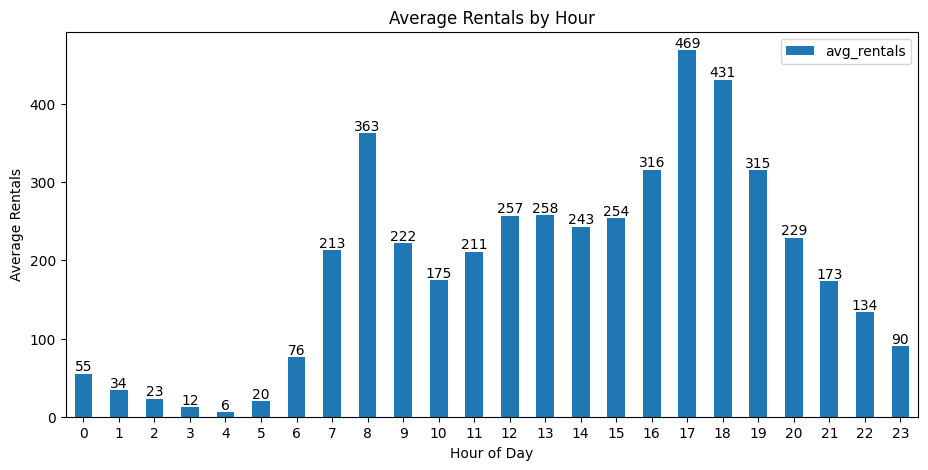

In [ ]:
#  groutping data by hours of the day segrating
hourly_stats = (df.groupby('hour')['count']
                .agg(avg_rentals = 'mean')
                .round(0)
                .reset_index()
                .sort_values(by='hour')

                )

#  this will create bar chart

ax = hourly_stats.plot(x='hour', y ='avg_rentals',kind='bar', figsize = (11,5))

#labeling the chart
ax.bar_label(ax.containers[0], fmt = '%.0f', label_type = 'edge')

plt.title("Average Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()


In this graph - the x axis is the hoour of the day ranging from 0-23 and y axis is the average rentald for the books

4) We clearly see -  There are two clear peak windows

1. Morning Peak → 7–9 AM
2. Evening Peak → 4–7 PM

In terms of business Business Importance - we can recommend that business can do Capacity Planning ie --Ensuring maximum bike availability during these peak hours
and the second business recommendation could be that during the low-demand hours (midnight–5 AM) business can do Maintenance Planning - ie
Schedule maintenance during those hours when demand is the lowest

In [ ]:
# Exporting the final dataframe as csv to use it in Tableau for visualization

df.to_csv("bike_rental.csv" , index=False)